In [1]:
# Import the standard data analytics libraries
import pandas as pd
import numpy as np

# Load the kaggle dataset into python memory
# Note: If your file name inside the folder is different, change it here
df = pd.read_csv('emotions.csv')

# Check the total number of rows and columns
print("--- Data Dimensions (Rows, Columns) ---")
print(df.shape)

# Show the first 3 rows of the data to see how it looks
print("\n--- Displaying Top 3 Rows ---")
df.head(3)


--- Data Dimensions (Rows, Columns) ---
(2132, 2549)

--- Displaying Top 3 Rows ---


,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.07,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.0,-162.0,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.55,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.6,-31.6,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.90,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.0,-148.0,281.00,POSITIVE


In [2]:
# 1. Missing Values Check (Kya koi Cell Khali hai?)
print("--- Missing Values Check ---")
total_nulls = df.isnull().sum().sum()
print(f"Total Missing Values in Dataset: {total_nulls}")

# 2. Target Emotion Class Balance (Konsa emotion kitni baar hai?)
print("\n--- Target Emotion Counts ---")
print(df['label'].value_counts())

# 3. Target Distribution Percentage (%)
print("\n--- Target Emotion Percentage (%) ---")
print(df['label'].value_counts(normalize=True) * 100)

--- Missing Values Check ---
Total Missing Values in Dataset: 0

--- Target Emotion Counts ---
label
NEUTRAL     716
NEGATIVE    708
POSITIVE    708
Name: count, dtype: int64

--- Target Emotion Percentage (%) ---
label
NEUTRAL     33.583490
NEGATIVE    33.208255
POSITIVE    33.208255
Name: proportion, dtype: float64


--- Count of Each Emotion Category ---
label
NEUTRAL     716
NEGATIVE    708
POSITIVE    708
Name: count, dtype: int64


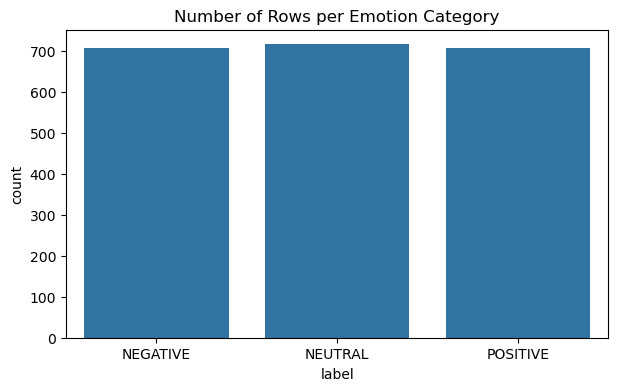

In [3]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Check how many rows belong to POSITIVE, NEGATIVE, and NEUTRAL
print("--- Count of Each Emotion Category ---")
print(df['label'].value_counts())

# Plot a simple Bar Chart to visualize the emotion categories
plt.figure(figsize=(7, 4))
sns.countplot(x='label', data=df)
plt.title("Number of Rows per Emotion Category")
plt.show()


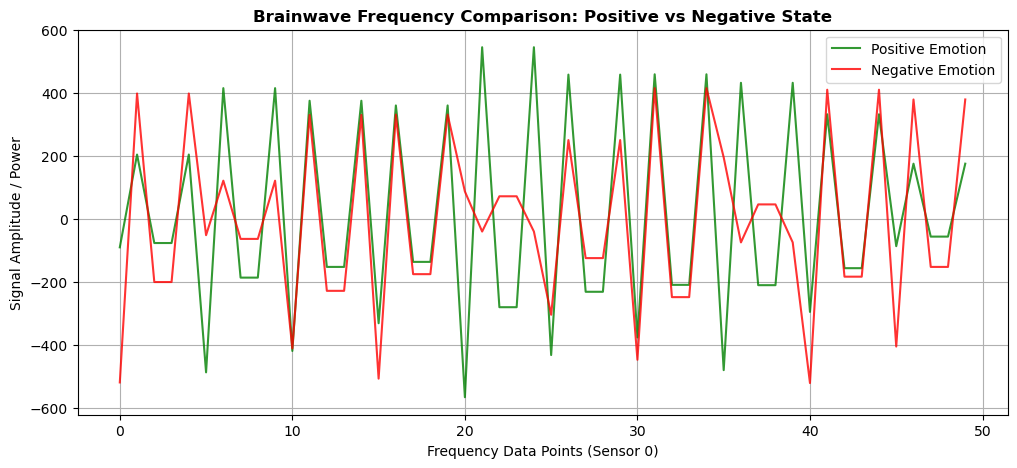

In [4]:
# 1. Filter out one row for a POSITIVE emotion
positive_wave = df[df['label'] == 'POSITIVE'].iloc[0]

# 2. Filter out one row for a NEGATIVE emotion
negative_wave = df[df['label'] == 'NEGATIVE'].iloc[0]

# 3. Select columns that belong to Fast Fourier Transform (fft) for sensor 0
# We are taking the first 50 data points to keep the graph readable
fft_columns = [f'fft_{i}_a' for i in range(50)]

# 4. Create the comparison line plot
plt.figure(figsize=(12, 5))

# Plot the positive emotion wave in green
plt.plot(positive_wave[fft_columns].values, label='Positive Emotion', color='green', alpha=0.8)

# Plot the negative emotion wave in red
plt.plot(negative_wave[fft_columns].values, label='Negative Emotion', color='red', alpha=0.8)

# Add labels, title, and legend to the graph
plt.title("Brainwave Frequency Comparison: Positive vs Negative State", fontsize=12, weight='bold')
plt.xlabel("Frequency Data Points (Sensor 0)", fontsize=10)
plt.ylabel("Signal Amplitude / Power", fontsize=10)
plt.legend()
plt.grid(True)
plt.show()


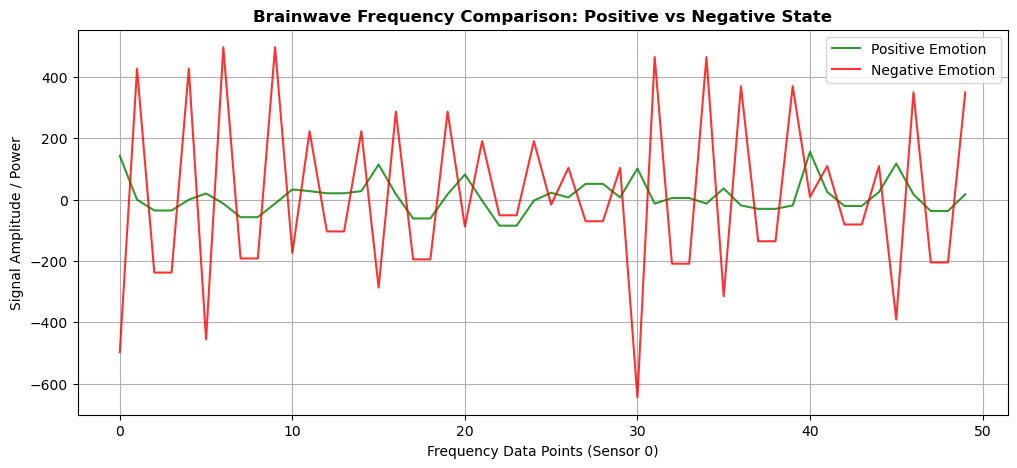

In [5]:
# 1. Filter out one row for a POSITIVE emotion
positive_wave = df[df['label'] == 'POSITIVE'].iloc[2]

# 2. Filter out one row for a NEGATIVE emotion
negative_wave = df[df['label'] == 'NEGATIVE'].iloc[2]

# 3. Select columns that belong to Fast Fourier Transform (fft) for sensor 2
# We are taking the first 50 data points to keep the graph readable
fft_columns = [f'fft_{i}_a' for i in range(50)]

# 4. Create the comparison line plot
plt.figure(figsize=(12, 5))

# Plot the positive emotion wave in green
plt.plot(positive_wave[fft_columns].values, label='Positive Emotion', color='green', alpha=0.8)

# Plot the negative emotion wave in red
plt.plot(negative_wave[fft_columns].values, label='Negative Emotion', color='red', alpha=0.8)

# Add labels, title, and legend to the graph
plt.title("Brainwave Frequency Comparison: Positive vs Negative State", fontsize=12, weight='bold')
plt.xlabel("Frequency Data Points (Sensor 0)", fontsize=10)
plt.ylabel("Signal Amplitude / Power", fontsize=10)
plt.legend()
plt.grid(True)
plt.show()


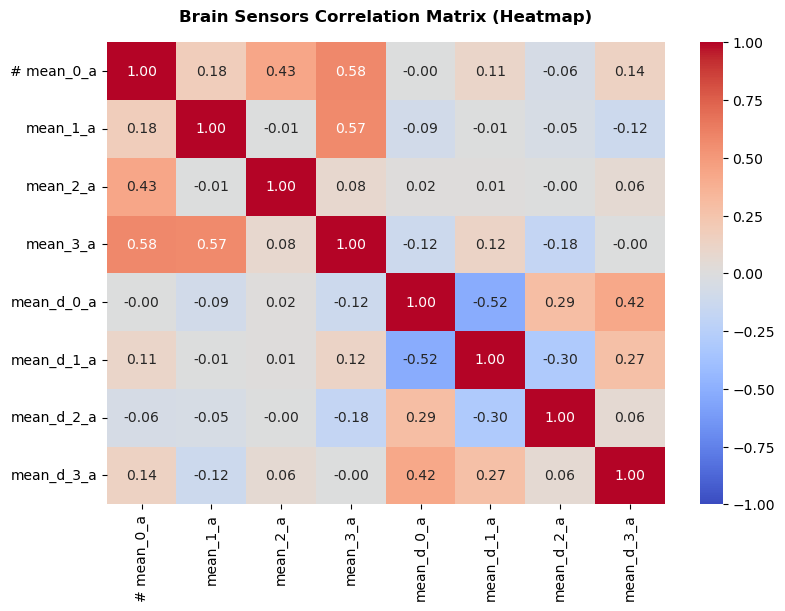

In [6]:
# 1. Select a few main mean columns to check their relationship
# We are picking 8 sample columns to keep the heatmap clean
sample_columns = ['# mean_0_a', 'mean_1_a', 'mean_2_a', 'mean_3_a', 
                  'mean_d_0_a', 'mean_d_1_a', 'mean_d_2_a', 'mean_d_3_a']

# 2. Calculate the correlation matrix (How columns change together)
correlation_matrix = df[sample_columns].corr()

# 3. Plot the multi-colored Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

# Add title to our final visualization matrix
plt.title("Brain Sensors Correlation Matrix (Heatmap)", fontsize=12, weight='bold', pad=15)
plt.show()


In [7]:
# Import the function to split our dataset
from sklearn.model_selection import train_test_split

# Step 1: Separate the input brain signals (X) and the target emotion label (y)
X = df.drop('label', axis=1)  # All columns except 'label' (2,549 signals)
y = df['label']              # Only the emotion column ('POSITIVE', 'NEGATIVE', 'NEUTRAL')

# Step 2: Split the data into Training (80%) and Testing (20%) sets
# random_state=42 ensures we get the exact same split every time we run this
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Step 3: Print the total counts to verify the split
print("--- Data Split Success! ---")
print(f"Total Training Samples (For Model Study): {X_train.shape[0]}")
print(f"Total Testing Samples (For Model Exam): {X_test.shape[0]}")

--- Data Split Success! ---
Total Training Samples (For Model Study): 1705
Total Testing Samples (For Model Exam): 427


In [8]:
# Import the Random Forest Classifier from sklearn
from sklearn.ensemble import RandomForestClassifier

# Step 1: Create our Random Forest Model (Creating a team of 100 Decision Trees)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Step 2: Train the model using our Training Data (1,705 samples)
print("Training the EEG Emotion Model... Please wait!")
rf_model.fit(X_train, y_train)

print("--- Model Training Complete! 🎉 ---")

Training the EEG Emotion Model... Please wait!
--- Model Training Complete! 🎉 ---


In [11]:
# Import Accuracy metric from sklearn
from sklearn.metrics import accuracy_score

# Step 1: Using Random Forest Model to predict 427 samples
y_pred = rf_model.predict(X_test)

# Step 2: Comparing predicted value from actual value
accuracy = accuracy_score(y_test, y_pred)

# Step 3: Print Accuracy Percentage
print(f"--- Model Performance Result ---")
print(f"Accuracy Score: {accuracy * 100:.2f}%")

--- Model Performance Result ---
Accuracy Score: 98.83%


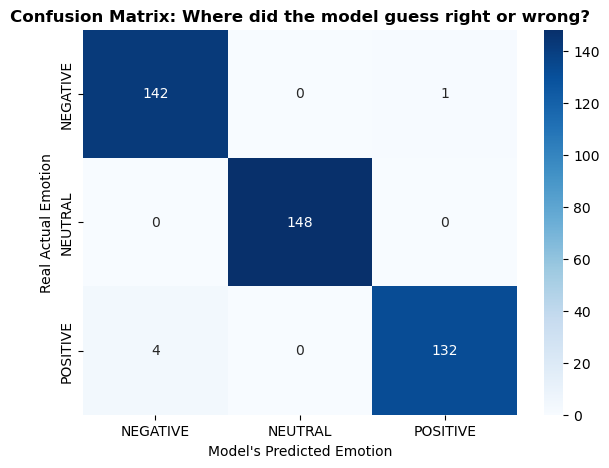

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    NEGATIVE       0.97      0.99      0.98       143
     NEUTRAL       1.00      1.00      1.00       148
    POSITIVE       0.99      0.97      0.98       136

    accuracy                           0.99       427
   macro avg       0.99      0.99      0.99       427
weighted avg       0.99      0.99      0.99       427



In [12]:
# Import evaluation tools from sklearn
from sklearn.metrics import confusion_matrix, classification_report

# Step 1: Generate the Confusion Matrix array
cm = confusion_matrix(y_test, y_pred)

# Step 2: Plot the Confusion Matrix as a colorful Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_)

# Labels and Titles
plt.title("Confusion Matrix: Where did the model guess right or wrong?", fontsize=12, weight='bold')
plt.xlabel("Model's Predicted Emotion", fontsize=10)
plt.ylabel("Real Actual Emotion", fontsize=10)
plt.show()

# Step 3: Print Detailed Precision, Recall, and F1-Score
print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

In [13]:
# Check for any missing values (NaN) in the entire dataset
print("Total Missing Values in Dataset:", df.isnull().sum().sum())

# Get a quick statistical summary (mean, min, max) of our selected features
print("\n--- Statistical Summary of Brain Waves ---")
df[sample_columns].describe()


Total Missing Values in Dataset: 0

--- Statistical Summary of Brain Waves ---


,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a
count,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000
mean,15.256914,27.012462,-104.975629,13.605898,0.025378,0.052282,0.301655,0.036793
std,15.284621,9.265141,206.271960,16.874676,17.981796,8.509174,68.098894,17.010031
min,-61.300000,-114.000000,-970.000000,-137.000000,-218.000000,-255.000000,-1360.000000,-203.000000
25%,6.577500,26.075000,-195.000000,4.857500,-3.105000,-1.340000,-4.002500,-2.905000
50%,14.100000,30.000000,14.950000,15.400000,-0.044600,0.132000,0.957500,-0.099750
75%,27.700000,31.400000,29.600000,26.500000,2.920000,1.540000,6.735000,2.535000
max,304.000000,42.300000,661.000000,206.000000,402.000000,257.000000,1150.000000,349.000000
